# GOOGL Stock Movement Prediction
## Part 3: Exploratory Data Analysis

This notebook analyzes the feature matrix from Part 2 across eight angles:

1. Target variable distribution and stationarity
2. Feature-target correlation by horizon
3. Multicollinearity diagnosis (157 columns — expect redundancy)
4. Time series visualization of price, volume, and key fundamentals
5. Missing value pattern
6. Feature distribution and skewness
7. Stationarity testing (ADF) on return-based features
8. Feature selection recommendation for Part 4

Train-only data is used for all statistical decisions (correlation,
stationarity, redundancy) to avoid leaking information from validation
or test periods into the feature selection process.

In [1]:
!pip install pandas numpy matplotlib seaborn scipy statsmodels -q

In [2]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

PROCESSED_DIR = "data/processed"

df = pd.read_csv(f"{PROCESSED_DIR}/features.csv", index_col=0, parse_dates=True)

with open(f"{PROCESSED_DIR}/split_index.json") as fh:
    split_index = json.load(fh)

with open(f"{PROCESSED_DIR}/feature_groups.json") as fh:
    feature_groups = json.load(fh)

# Train-only slice for all statistical analysis in this notebook
train_df = df[(df.index >= split_index["train_start"]) & (df.index <= split_index["train_end"])]

print(f"Full dataset : {df.shape}")
print(f"Train slice  : {train_df.shape}  ({split_index['train_start']} to {split_index['train_end']})")

target_cols  = feature_groups["targets"]
feature_cols = [c for c in df.columns if c not in target_cols and c not in feature_groups["ohlcv"]]
print(f"Candidate feature columns (excluding OHLCV and targets): {len(feature_cols)}")

Full dataset : (3134, 157)
Train slice  : (2015, 157)  (2014-01-01 to 2021-12-31)
Candidate feature columns (excluding OHLCV and targets): 149


## Target Variable Distribution and Stationarity

Returns are generally stationary by construction (unlike raw price levels),
but it is still worth confirming this formally and checking for regime
changes across the training period.

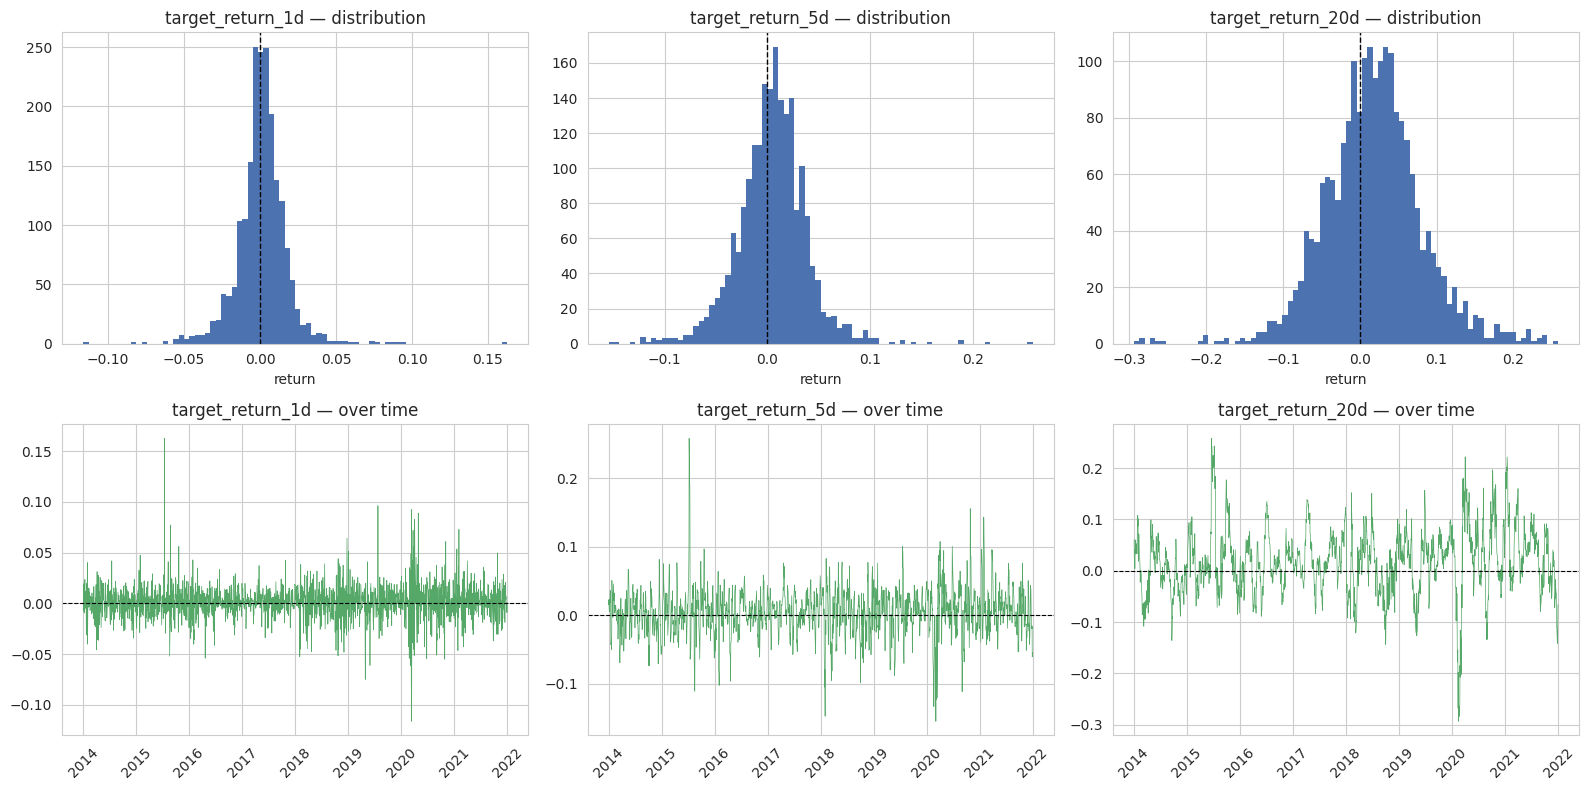

Skewness and kurtosis (train only):
  target_return_1d       skew=+0.399  kurtosis=+9.548
  target_return_5d       skew=+0.240  kurtosis=+4.386
  target_return_20d      skew=-0.076  kurtosis=+2.004


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(target_cols):
    axes[0, i].hist(train_df[col].dropna(), bins=80, color="#4C72B0", edgecolor="none")
    axes[0, i].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[0, i].set_title(f"{col} — distribution")
    axes[0, i].set_xlabel("return")

    axes[1, i].plot(train_df.index, train_df[col], linewidth=0.5, color="#55A868")
    axes[1, i].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[1, i].set_title(f"{col} — over time")
    axes[1, i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("target_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

print("Skewness and kurtosis (train only):")
for col in target_cols:
    s = train_df[col].dropna()
    print(f"  {col:<22} skew={s.skew():+.3f}  kurtosis={s.kurtosis():+.3f}")

In [4]:
print("Augmented Dickey-Fuller test (H0: series has a unit root / is non-stationary)")
print()
for col in target_cols:
    series = train_df[col].dropna()
    result = adfuller(series, autolag="AIC")
    print(f"  {col}")
    print(f"    ADF statistic : {result[0]:.4f}")
    print(f"    p-value       : {result[1]:.6f}")
    print(f"    Stationary    : {'Yes' if result[1] < 0.05 else 'No'} (alpha=0.05)")
    print()

Augmented Dickey-Fuller test (H0: series has a unit root / is non-stationary)

  target_return_1d
    ADF statistic : -10.0602
    p-value       : 0.000000
    Stationary    : Yes (alpha=0.05)

  target_return_5d
    ADF statistic : -8.5028
    p-value       : 0.000000
    Stationary    : Yes (alpha=0.05)

  target_return_20d
    ADF statistic : -7.4132
    p-value       : 0.000000
    Stationary    : Yes (alpha=0.05)



## Feature-Target Correlation by Horizon

Spearman correlation is used instead of Pearson because several features
(RSI, Stochastic, ratios) are bounded or non-linear in their relationship
with returns. Spearman captures monotonic relationships without assuming
linearity.

In [5]:
correlations = {}
for target in target_cols:
    corr = train_df[feature_cols].corrwith(train_df[target], method="spearman")
    correlations[target] = corr.sort_values(key=np.abs, ascending=False)

for target in target_cols:
    print(f"Top 15 features by |Spearman correlation| with {target}:")
    print(correlations[target].head(15).to_string())
    print()

Top 15 features by |Spearman correlation| with target_return_1d:
stoch_d             -0.090078
rsi_14              -0.077309
williams_r          -0.071396
stoch_k             -0.071396
keltner_position    -0.070245
log_return_10d      -0.069679
log_return_5d       -0.068282
price_to_ema_10     -0.067774
price_to_ema_20     -0.066172
price_to_sma_20     -0.065968
donchian_position   -0.064988
price_to_sma_10     -0.064719
wick_upper_ratio     0.064397
vix_regime           0.064030
price_to_vwap       -0.063960

Top 15 features by |Spearman correlation| with target_return_5d:
stoch_k             -0.151144
williams_r          -0.151144
stoch_d             -0.141552
log_return_10d      -0.140465
price_to_ema_10     -0.134194
keltner_position    -0.133851
price_to_sma_10     -0.130148
bb_position         -0.128657
price_to_ema_20     -0.128564
cci_20              -0.121760
obv_momentum        -0.120870
price_to_ema_5      -0.118637
price_to_ema_50     -0.117255
donchian_position   -0.116433

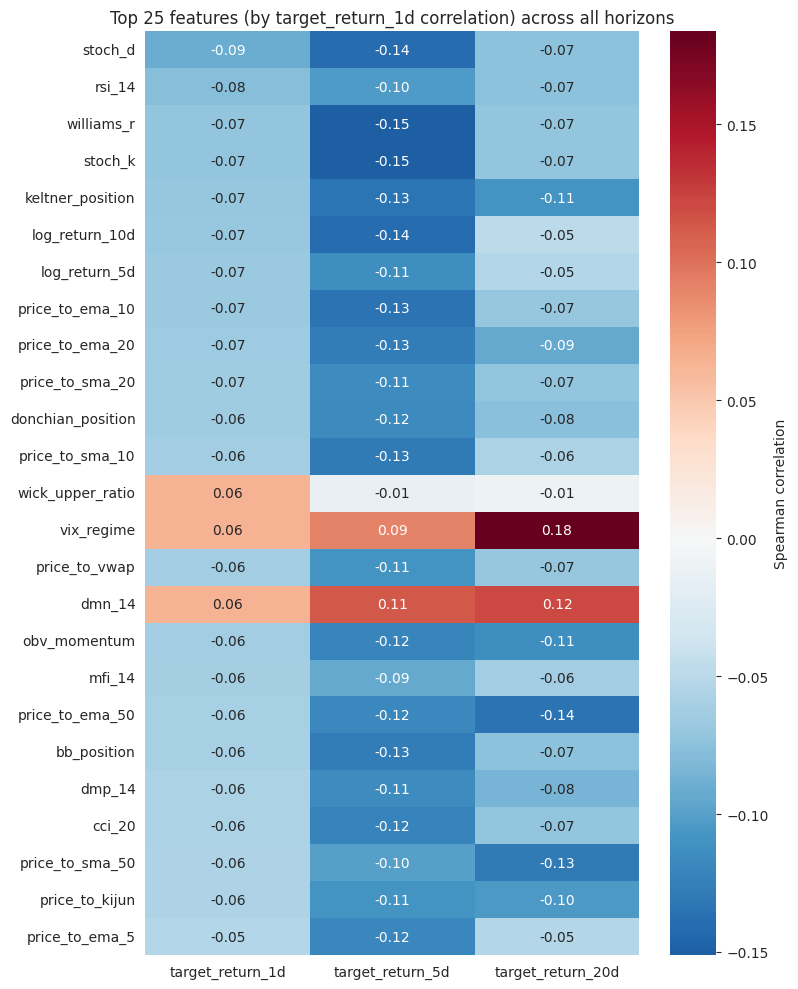

In [6]:
top_n = 25
top_features_1d = correlations["target_return_1d"].head(top_n).index.tolist()

fig, ax = plt.subplots(figsize=(8, 10))
corr_matrix = pd.DataFrame({t: correlations[t] for t in target_cols}).loc[top_features_1d]
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Spearman correlation"})
ax.set_title(f"Top {top_n} features (by target_return_1d correlation) across all horizons")
plt.tight_layout()
plt.savefig("feature_target_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

## Multicollinearity Diagnosis

With 157 columns including multiple SMA/EMA windows, multiple oscillators
computed from similar inputs, and ratio variants, substantial redundancy is
expected. High pairwise correlation (|r| > 0.95) among features inflates
variance in linear models and wastes capacity in tree-based and attention
models without adding signal.

This section identifies redundant pairs to drop before modeling — keeping
one representative per cluster.

In [7]:
numeric_features = train_df[feature_cols].select_dtypes(include=[np.number])
feature_corr = numeric_features.corr(method="spearman").abs()

# Upper triangle only, to avoid duplicate pairs and self-correlation
upper_triangle = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))

REDUNDANCY_THRESHOLD = 0.95
redundant_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
)
redundant_pairs = redundant_pairs[redundant_pairs["correlation"] > REDUNDANCY_THRESHOLD]
redundant_pairs = redundant_pairs.sort_values("correlation", ascending=False)

print(f"Pairs with |Spearman r| > {REDUNDANCY_THRESHOLD}: {len(redundant_pairs)}")
print(redundant_pairs.to_string(index=False))

Pairs with |Spearman r| > 0.95: 225
           feature_1              feature_2  correlation
             stoch_k             williams_r     1.000000
        equity_ratio                  az_x4     1.000000
        gross_margin             cost_ratio     1.000000
       current_ratio            quick_ratio     1.000000
      debt_to_assets           equity_ratio     1.000000
      debt_to_assets                  az_x4     1.000000
receivables_turnover days_sales_outstanding     1.000000
               sma_5                  ema_5     0.999867
              sma_20               vwap_20d     0.999781
              sma_10                 ema_10     0.999722
              sma_20                 ema_20     0.999483
               ema_5                 ema_10     0.999478
               sma_5                 ema_10     0.999396
              ema_20               vwap_20d     0.999323
              ema_10                 ema_20     0.998998
              sma_10                  ema_5     0.99

In [8]:
# For each redundant pair, drop the feature with weaker correlation to
# target_return_5d (chosen as the primary horizon — a middle ground between
# noisy 1d and slow-moving 20d signal)
primary_target = "target_return_5d"
target_corr_abs = correlations[primary_target].abs()

to_drop = set()
for _, row in redundant_pairs.iterrows():
    f1, f2 = row["feature_1"], row["feature_2"]
    if f1 in to_drop or f2 in to_drop:
        continue
    score1 = target_corr_abs.get(f1, 0)
    score2 = target_corr_abs.get(f2, 0)
    to_drop.add(f1 if score1 < score2 else f2)

print(f"Features dropped due to redundancy: {len(to_drop)}")
print(sorted(to_drop))

reduced_features = [c for c in feature_cols if c not in to_drop]
print(f"\nFeature count: {len(feature_cols)} -> {len(reduced_features)}")

Features dropped due to redundancy: 38
['az_x1', 'az_x4', 'bb_lower', 'bb_upper', 'cci_20', 'cost_ratio', 'current_ratio', 'days_sales_outstanding', 'debt_to_assets', 'ema_10', 'ema_20', 'ema_5', 'ema_50', 'equity_ratio', 'goodwill_ratio', 'intangible_ratio', 'log_market_cap', 'nasdaq_composite', 'obv', 'obv_sma20', 'price_to_ema_20', 'price_to_sma_10', 'price_to_sma_20', 'price_to_sma_5', 'price_to_sma_50', 'price_to_vwap', 'quick_ratio', 'rd_qoq', 'roa', 'roic', 'sma_10', 'sma_20', 'sma_200', 'sma_5', 'sma_50', 'sp500', 'vwap_20d', 'williams_r']

Feature count: 149 -> 111


## Time Series Visualization

Volume mean: 36,599,864  |  std: 19,072,479
Days with volume > mean + 5*std: 10
               volume
date                 
2014-01-24  155544300
2014-01-27  173969856
2014-01-30  203452344
2014-01-31  222429348
2014-02-03  182581236
2014-03-27  152735112
2015-07-17  257162000
2016-02-02  135846000
2016-04-22  140798000
2019-04-30  133178000


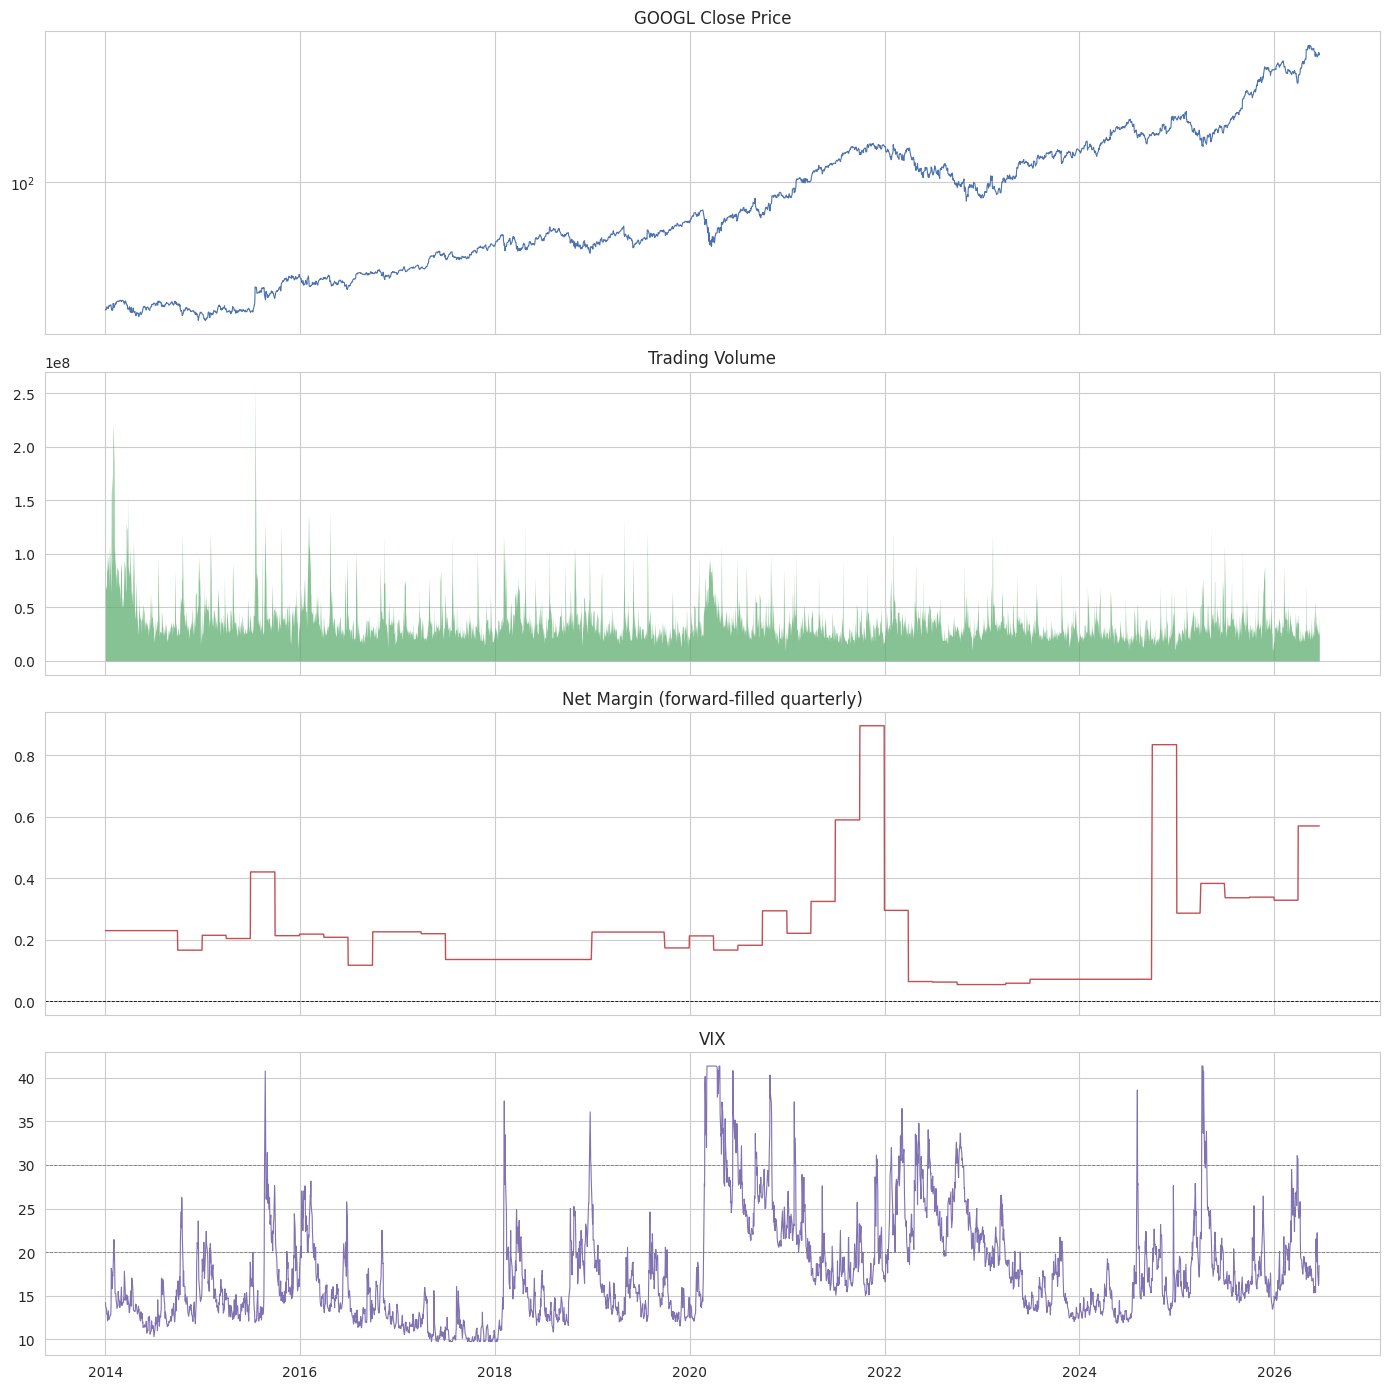

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(df.index, df["close"], color="#4C72B0", linewidth=0.8)
axes[0].set_title("GOOGL Close Price")
axes[0].set_yscale("log")

# Note: ax.bar() with width=1.0 renders as near-invisible sub-pixel bars
# when plotting ~3000+ daily points across a 12+ year axis. fill_between
# renders correctly at this point density.
axes[1].fill_between(df.index, df["volume"], color="#55A868", alpha=0.7, linewidth=0)
axes[1].set_title("Trading Volume")

vol_mean = df["volume"].mean()
vol_std  = df["volume"].std()
volume_outliers = df[df["volume"] > vol_mean + 5 * vol_std]
print(f"Volume mean: {vol_mean:,.0f}  |  std: {vol_std:,.0f}")
print(f"Days with volume > mean + 5*std: {len(volume_outliers)}")
if len(volume_outliers) > 0:
    print(volume_outliers[["volume"]].to_string())

axes[2].plot(df.index, df["net_margin"], color="#C44E52", linewidth=1.0)
axes[2].set_title("Net Margin (forward-filled quarterly)")
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.6)

axes[3].plot(df.index, df["vix"], color="#8172B2", linewidth=0.8)
axes[3].set_title("VIX")
axes[3].axhline(20, color="gray", linestyle="--", linewidth=0.6)
axes[3].axhline(30, color="gray", linestyle="--", linewidth=0.6)

plt.tight_layout()
plt.savefig("time_series_overview.png", dpi=120, bbox_inches="tight")
plt.show()

## Missing Value Pattern

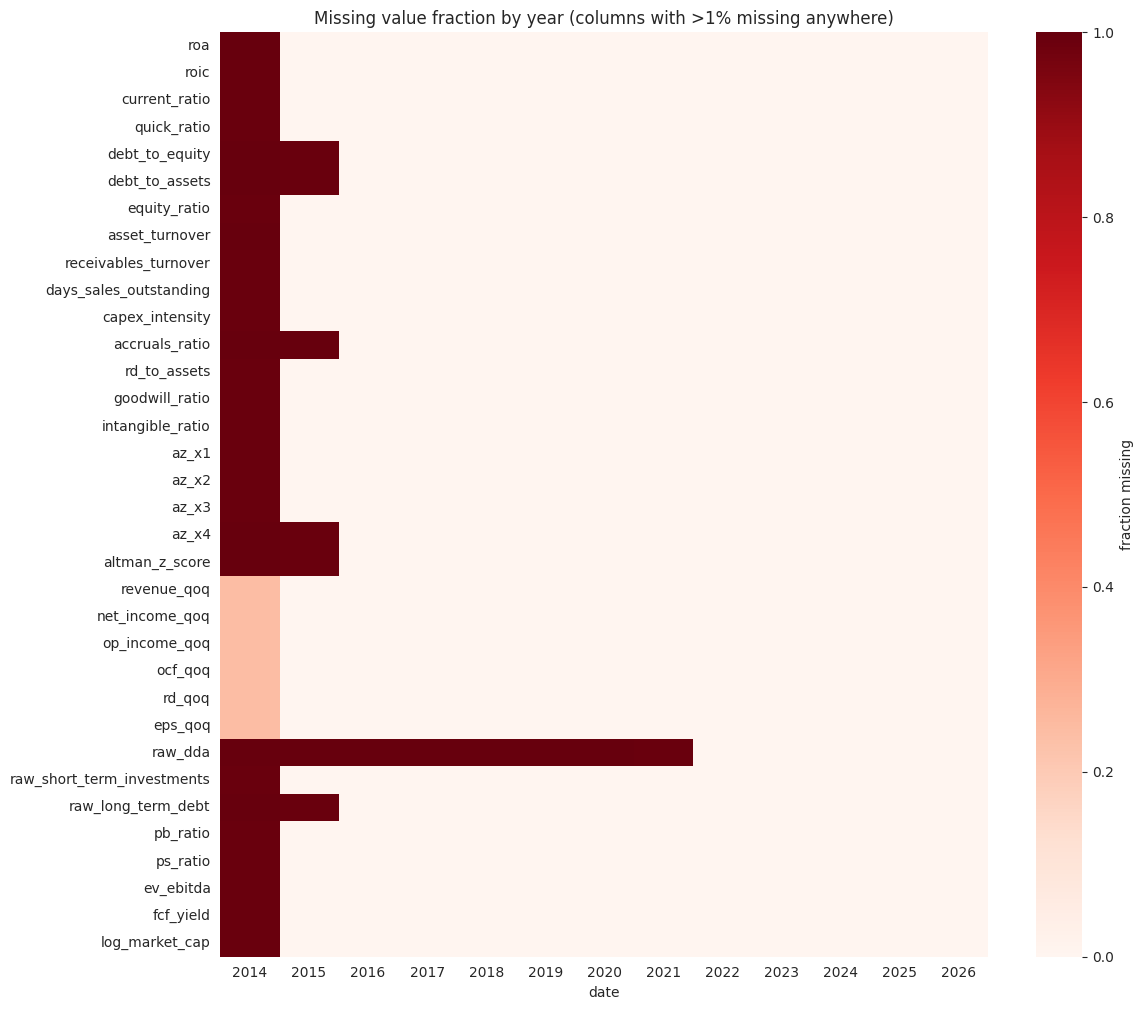

In [10]:
missing_by_year = df[feature_cols].isnull().groupby(df.index.year).mean()
cols_with_any_missing = missing_by_year.columns[missing_by_year.max() > 0.01]

if len(cols_with_any_missing) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(cols_with_any_missing) * 0.3)))
    sns.heatmap(
        missing_by_year[cols_with_any_missing].T,
        cmap="Reds", cbar_kws={"label": "fraction missing"}, ax=ax
    )
    ax.set_title("Missing value fraction by year (columns with >1% missing anywhere)")
    plt.tight_layout()
    plt.savefig("missing_value_pattern.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No columns with material missing values to visualize.")

## Feature Distribution and Skewness

Tree-based models (LightGBM) are invariant to monotonic transformations and
do not require addressing skew. Transformer-based models (TFT, iTransformer)
benefit from approximately normalized inputs, since extreme skew can
dominate attention weights and gradient magnitudes. This section flags
candidates for log-transformation prior to use in the deep learning models.

Features with |skewness| > 2: 19
dda                       44.888751
pb_ratio                  36.882398
long_term_debt            20.014965
short_term_investments    15.787654
cpi_mom                    7.357424
net_income_qoq             3.187029
net_margin                 3.078487
pf_leverage_dec            2.768730
eps_qoq                    2.752360
op_income_qoq              2.629189
pe_ratio                   2.585687
unemployment_rate          2.406684
gross_margin              -2.390195
cost_ratio                 2.390195
rd_ratio                   2.311414
pf_roa_pos                -2.268619
sga_ratio                  2.134865
revenue_qoq                2.102689
rd_qoq                     2.049469


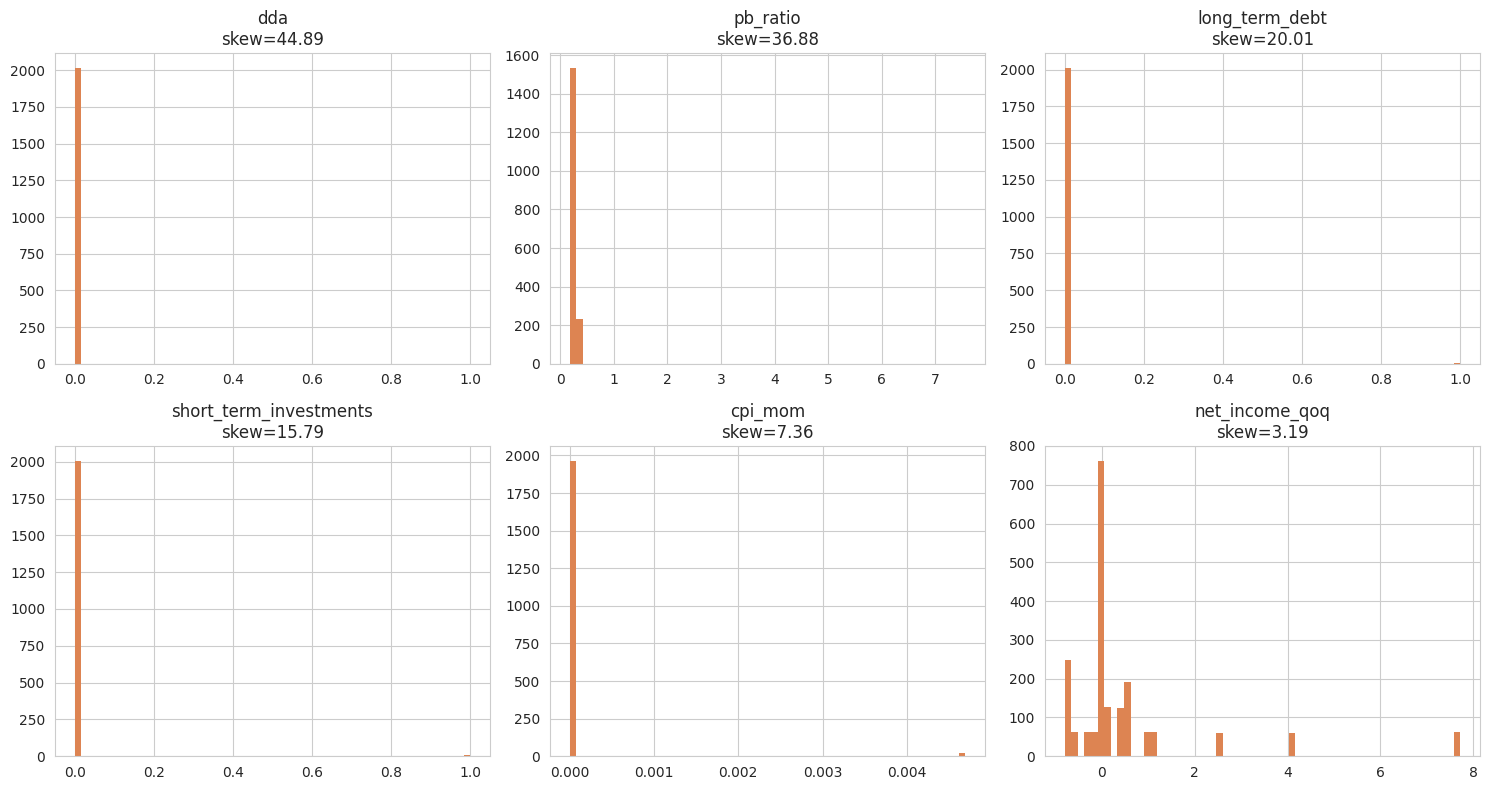

In [11]:
skewness = train_df[feature_cols].skew().sort_values(key=np.abs, ascending=False)
high_skew = skewness[skewness.abs() > 2]

print(f"Features with |skewness| > 2: {len(high_skew)}")
print(high_skew.to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, high_skew.index[:6]):
    ax.hist(train_df[col].dropna(), bins=60, color="#DD8452", edgecolor="none")
    ax.set_title(f"{col}\nskew={skewness[col]:.2f}")
plt.tight_layout()
plt.savefig("high_skew_features.png", dpi=120, bbox_inches="tight")
plt.show()

## Stationarity Testing on Return-Based Features

Log-return and ratio-based features should already be approximately
stationary by construction (unlike raw levels such as SMA or VWAP, which
trend with price). This section confirms the distinction and flags any
level-based features that should be excluded or differenced before use in
models sensitive to non-stationarity.

In [12]:
def run_adf(series: pd.Series) -> float:
    series = series.dropna()
    if len(series) < 30:
        return np.nan
    try:
        return adfuller(series, autolag="AIC")[1]
    except Exception:
        return np.nan


adf_results = {}
for col in feature_cols:
    adf_results[col] = run_adf(train_df[col])

adf_series = pd.Series(adf_results).sort_values()
non_stationary = adf_series[adf_series > 0.05]

print(f"Features failing ADF stationarity test (p > 0.05): {len(non_stationary)} / {len(adf_series)}")
print()
print("Non-stationary features (likely level-based, e.g. SMA, VWAP, raw fundamentals):")
print(non_stationary.to_string())

Features failing ADF stationarity test (p > 0.05): 55 / 149

Non-stationary features (likely level-based, e.g. SMA, VWAP, raw fundamentals):
net_margin                    0.061166
pe_ratio                      0.071380
pf_roa_improving              0.080284
pf_margin_inc                 0.080477
pf_roa_pos                    0.083439
raw_short_term_investments    0.106157
yield_spread_10_2             0.139519
pf_leverage_dec               0.153055
usd_index                     0.160982
roe                           0.222722
pf_no_dilution                0.242309
piotroski_f_score             0.254161
oil_price_wti                 0.279992
roa                           0.351502
pf_liquidity_inc              0.354051
pf_accruals_low               0.414825
treasury_10y                  0.462529
intangible_ratio              0.470748
breakeven_inflation_10y       0.493242
goodwill_ratio                0.710611
treasury_2y                   0.713595
fed_funds_rate                0.737254
r

## Feature Selection Recommendation

Combining the redundancy analysis (Section 3) with the stationarity check
(Section 7) and correlation ranking (Section 2), this section produces the
final recommended feature list for Part 4.

**Decision logic:**
- Drop features flagged as redundant (Section 3)
- Keep non-stationary level features (SMA, EMA, VWAP, raw fundamentals) for
  LightGBM, since tree splits handle non-stationary levels without issue
- For TFT/iTransformer, recommend using only normalized/ratio versions
  (`price_to_sma_*` rather than `sma_*`) since these architectures are more
  sensitive to non-stationary inputs

In [14]:
# The earlier hardcoded level-feature list undercounts: redundancy removal in
# Section 3 already dropped most raw sma_*/ema_*/bb_* columns, so checking
# membership in a fixed name list against reduced_features misses other level
# or non-stationary features that survived redundancy filtering (e.g. sma_200,
# obv, pb_ratio, roa, debt_to_equity). The ADF results from Section 7 are the
# authoritative source for what is actually non-stationary in this feature set.

# Binary/categorical columns (Piotroski components, vix_regime) fail or are
# meaningless under ADF by construction, not because they are unbounded level
# features — they are excluded from the drop list since they need no
# normalization regardless of stationarity test outcome.

binary_or_categorical = {c for c in reduced_features if df[c].dropna().nunique() <= 3}
non_stationary_set = set(non_stationary.index) - binary_or_categorical
level_or_nonstationary_in_reduced = [c for c in reduced_features if c in non_stationary_set]

tree_model_features = reduced_features  # LightGBM: keep levels, tree splits handle them natively
sequence_model_features = [c for c in reduced_features if c not in non_stationary_set]

print(f"Binary/categorical features excluded from drop logic: {sorted(binary_or_categorical)}")
print()
print(f"Non-stationary features remaining after redundancy removal: {len(level_or_nonstationary_in_reduced)}")
print(level_or_nonstationary_in_reduced)
print()
print(f"Tree model (LightGBM) feature count             : {len(tree_model_features)}")
print(f"Sequence model (TFT/iTransformer) feature count  : {len(sequence_model_features)}")

eda_report = {
    "n_features_original": len(feature_cols),
    "n_features_after_redundancy_removal": len(reduced_features),
    "redundant_features_dropped": sorted(to_drop),
    "high_skew_features": high_skew.index.tolist(),
    "non_stationary_features": non_stationary.index.tolist(),
    "top_correlated_features_1d": correlations["target_return_1d"].head(20).index.tolist(),
    "top_correlated_features_5d": correlations["target_return_5d"].head(20).index.tolist(),
    "top_correlated_features_20d": correlations["target_return_20d"].head(20).index.tolist(),
}

selected_features = {
    "tree_model_features": tree_model_features,
    "sequence_model_features": sequence_model_features,
    "target_columns": target_cols,
}

with open(f"{PROCESSED_DIR}/eda_report.json", "w") as fh:
    json.dump(eda_report, fh, indent=2)

with open(f"{PROCESSED_DIR}/selected_features.json", "w") as fh:
    json.dump(selected_features, fh, indent=2)

print("  EDA SUMMARY")
print(f"  Original features          : {len(feature_cols)}")
print(f"  After redundancy removal   : {len(reduced_features)}")
print(f"  High skew (|skew|>2)       : {len(high_skew)}")
print(f"  Non-stationary (ADF p>0.05): {len(non_stationary)}")
print()
print(f"  eda_report.json        : {PROCESSED_DIR}/eda_report.json")
print(f"  selected_features.json : {PROCESSED_DIR}/selected_features.json")
print()
print("  Ready for Part 4: Modeling (LightGBM baseline)")

Binary/categorical features excluded from drop logic: ['candle_direction', 'dda', 'gdp_qoq', 'long_term_debt', 'pf_accruals_low', 'pf_leverage_dec', 'pf_liquidity_inc', 'pf_margin_inc', 'pf_no_dilution', 'pf_ocf_pos', 'pf_roa_improving', 'pf_roa_pos', 'pf_turnover_inc', 'short_term_investments', 'vix_regime']

Non-stationary features remaining after redundancy removal: 22
['net_margin', 'roe', 'debt_to_equity', 'piotroski_f_score', 'az_x2', 'altman_z_score', 'raw_short_term_investments', 'raw_long_term_debt', 'fed_funds_rate', 'treasury_10y', 'treasury_2y', 'cpi', 'real_gdp', 'oil_price_wti', 'usd_index', 'breakeven_inflation_10y', 'yield_spread_10_2', 'real_rate_10y', 'pe_ratio', 'pb_ratio', 'ps_ratio', 'ev_ebitda']

Tree model (LightGBM) feature count             : 111
Sequence model (TFT/iTransformer) feature count  : 89
  EDA SUMMARY
  Original features          : 149
  After redundancy removal   : 111
  High skew (|skew|>2)       : 19
  Non-stationary (ADF p>0.05): 55

  eda_repor